In [4]:
import os
import re
import warnings
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings('ignore')

In [5]:
# --------------------------------------------------
# 1. CẤU HÌNH ĐƯỜNG DẪN & ĐỌC DỮ LIỆU
# --------------------------------------------------
CURRENT_DIR = os.getcwd()
BASE_DIR = os.path.dirname(CURRENT_DIR) if 'notebooks' in CURRENT_DIR else CURRENT_DIR

RAW_DATA_PATH = os.path.join(BASE_DIR, 'data', 'raw', 'DuLieuGiaNhaHCM2024.csv')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'best_model.pkl')

print("Đường dẫn file dữ liệu:", RAW_DATA_PATH)
print("Đường dẫn lưu mô hình:", MODEL_SAVE_PATH)

if not os.path.exists(RAW_DATA_PATH):
    raise FileNotFoundError(f"Không tìm thấy file dữ liệu tại: {RAW_DATA_PATH}")

try:
    df = pd.read_csv(RAW_DATA_PATH, sep=None, engine='python', encoding='utf-16')
except Exception:
    df = pd.read_csv(RAW_DATA_PATH, sep=None, engine='python', encoding='utf-8-sig')

print("Đã tải dữ liệu thành công!")
print(f"Số dòng: {df.shape[0]}, Số cột: {df.shape[1]}")
display(df.head())


Đường dẫn file dữ liệu: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\data\raw\DuLieuGiaNhaHCM2024.csv
Đường dẫn lưu mô hình: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\models\best_model.pkl
Đã tải dữ liệu thành công!
Số dòng: 11780, Số cột: 10


,Address,Area,Frontage,Access Road,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,2.0,2.0,3.0,Have certificate,Full,5.35
1,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,2.0,4.0,4.0,Have certificate,Full,6.90
2,"Đường Phạm Văn Chiêu, Phường 14, Gò Vấp, Hồ Ch...",30.0,NaN,NaN,2.0,2.0,2.0,Have certificate,Full,3.79
3,"Đường Quang Trung, Phường 12, Gò Vấp, Hồ Chí Minh",46.0,4.6,6.0,4.0,4.0,5.0,Have certificate,Full,7.99
4,"Đường Ngô Tất Tố, Phường 22, Bình Thạnh, Hồ Ch...",60.0,3.5,5.0,2.0,6.0,5.0,Have certificate,Full,5.60


In [6]:
# --------------------------------------------------
# 2. LÀM SẠCH DỮ LIỆU
# --------------------------------------------------
df = df.replace([np.inf, -np.inf], np.nan).dropna()

before_dup = df.shape[0]
df = df.drop_duplicates()
print(f"\nLoại trùng lặp: {before_dup} -> {df.shape[0]} dòng")

TARGET_COL = 'Price'

y_raw = pd.to_numeric(df[TARGET_COL], errors='coerce')
valid_idx = y_raw.notna()
df = df[valid_idx].copy()
df[TARGET_COL] = y_raw[valid_idx]

def extract_district(address):
    address = str(address).strip()
    parts = [p.strip() for p in address.split(',')]
    parts = [p for p in parts if p]

    if len(parts) >= 2:
        district = parts[-2]
    else:
        district = parts[-1] if parts else 'Unknown'

    district = re.sub(r'[.\s]+$', '', district).strip()
    return district

if 'Address' in df.columns:
    df['District'] = df['Address'].apply(extract_district)
    df = df.drop(columns=['Address'])

    print(f"\nSố lượng Quận/Huyện khác nhau: {df['District'].nunique()}")
    print(df['District'].value_counts())

    district_counts = df['District'].value_counts()
    rare_districts = district_counts[district_counts < 10].index
    if len(rare_districts) > 0:
        print(f"\nGộp {len(rare_districts)} quận/huyện có < 10 mẫu vào nhóm 'Khác'")
        df['District'] = df['District'].replace(rare_districts, 'Khác')
        print(df['District'].value_counts())

Q1 = df[TARGET_COL].quantile(0.25)
Q3 = df[TARGET_COL].quantile(0.75)
IQR = Q3 - Q1
before_outlier = df.shape[0]
df = df[(df[TARGET_COL] >= Q1 - 1.5 * IQR) & (df[TARGET_COL] <= Q3 + 1.5 * IQR)]
print(f"\nLoại outlier: {before_outlier} -> {df.shape[0]} dòng")


Loại trùng lặp: 3127 -> 3125 dòng

Số lượng Quận/Huyện khác nhau: 26
District
Bình Tân             371
Gò Vấp               353
Quận 12              319
Thủ Đức              304
Bình Thạnh           262
Tân Bình             233
Tân Phú              198
Quận 7               192
Quận 9               173
Nhà Bè               119
Quận 8               101
Phú Nhuận             96
Quận 6                73
Hóc Môn               64
Quận 10               57
Bình Chánh            39
Quận 11               38
Quận 3                37
Quận 4                33
Quận 1                29
Quận 2                19
Củ Chi                 7
Thành phố Thủ Đức      3
Quận 5                 3
Quận Bình Tân          1
Quận Tân Phú           1
Name: count, dtype: int64

Gộp 5 quận/huyện có < 10 mẫu vào nhóm 'Khác'
District
Bình Tân      371
Gò Vấp        353
Quận 12       319
Thủ Đức       304
Bình Thạnh    262
Tân Bình      233
Tân Phú       198
Quận 7        192
Quận 9        173
Nhà Bè        119
Quận 8    

In [7]:
# --------------------------------------------------
# 3. FEATURE ENGINEERING
# --------------------------------------------------
if 'Frontage' in df.columns and 'Area' in df.columns:
    df['Frontage_Area_Ratio'] = df['Frontage'] / (df['Area'] + 1)

if 'Bedrooms' in df.columns and 'Bathrooms' in df.columns:
    df['Total_Rooms'] = df['Bedrooms'] + df['Bathrooms']
    if 'Floors' in df.columns:
        df['Rooms_per_Floor'] = df['Total_Rooms'] / (df['Floors'] + 1)

print("\nCác cột sau khi Feature Engineering:")
print(df.columns.tolist())


Các cột sau khi Feature Engineering:
['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Legal status', 'Furniture state', 'Price', 'District', 'Frontage_Area_Ratio', 'Total_Rooms', 'Rooms_per_Floor']



--- Tương quan với Price ---
Price                  1.000000
Total_Rooms            0.491197
Bathrooms              0.482619
Bedrooms               0.449361
Area                   0.421601
Floors                 0.411892
Access Road            0.266544
Rooms_per_Floor        0.219463
Frontage               0.082469
Frontage_Area_Ratio   -0.202830
Name: Price, dtype: float64


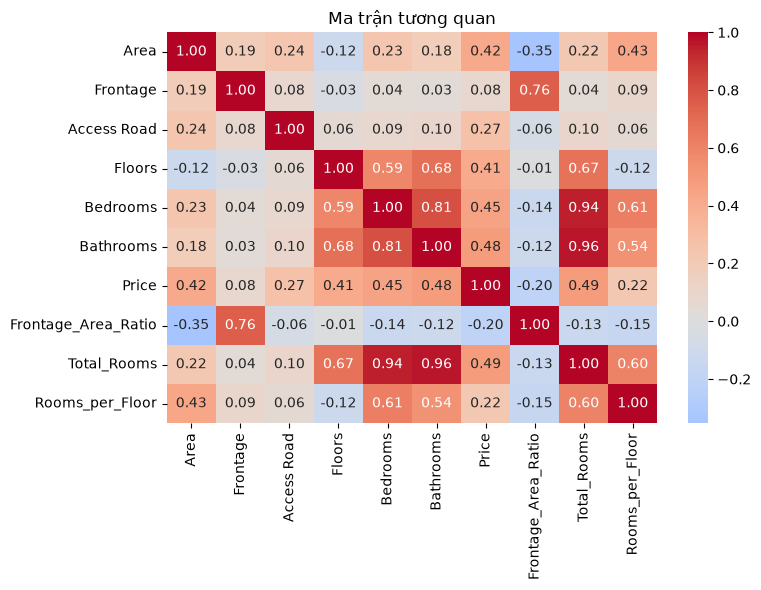

In [8]:
# --------------------------------------------------
# 4. KIỂM TRA TƯƠNG QUAN
# --------------------------------------------------
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()[TARGET_COL].sort_values(ascending=False)
print("\n--- Tương quan với Price ---")
print(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Ma trận tương quan')
plt.tight_layout()
plt.show()

In [9]:
# --------------------------------------------------
# 5. CHIA TRAIN/TEST & LOG-TRANSFORM TARGET
# --------------------------------------------------
ignore_cols = [TARGET_COL, 'id', 'date']
X = df.drop(columns=[col for col in ignore_cols if col in df.columns])
y = df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(f"\nKích thước tập Train: {X_train.shape}")
print(f"Kích thước tập Test : {X_test.shape}")


Kích thước tập Train: (2500, 12)
Kích thước tập Test : (625, 12)


In [10]:
# --------------------------------------------------
# 6. PIPELINE MÃ HOÁ
# --------------------------------------------------
CAT_COLS = X_train.select_dtypes(include=['object', 'string']).columns.tolist()
NUM_COLS = [c for c in X_train.columns if c not in CAT_COLS]

print(f"\nCột phân loại (Target Encode): {CAT_COLS}")
print(f"Cột số: {NUM_COLS}")

preprocessor = ColumnTransformer([
    ('cat', TargetEncoder(target_type='continuous'), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS),
])



Cột phân loại (Target Encode): ['Legal status', 'Furniture state', 'District']
Cột số: ['Area', 'Frontage', 'Access Road', 'Floors', 'Bedrooms', 'Bathrooms', 'Frontage_Area_Ratio', 'Total_Rooms', 'Rooms_per_Floor']


In [11]:
# --------------------------------------------------
# 7. ĐỊNH NGHĨA VÀ ĐÁNH GIÁ ĐA MÔ HÌNH (CROSS-VALIDATION)
# --------------------------------------------------
models = {
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1))
    ]),
    'Gradient Boosting': Pipeline([
        ('preprocessor', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=200, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('model', XGBRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42
        ))
    ]),
    'LightGBM': Pipeline([
        ('preprocessor', preprocessor),
        ('model', LGBMRegressor(
            n_estimators=300, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1
        ))
    ]),
}

kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

print("\n--- Đánh giá Cross-Validation (R2 Score, trên giá đã log-transform) ---")
for name, model_pipe in models.items():
    scores = cross_val_score(model_pipe, X_train, y_train_log, cv=kf, scoring='r2', n_jobs=-1)
    results.append({'Model': name, 'CV R2 Mean': scores.mean(), 'CV R2 Std': scores.std()})
    print(f"• {name}: {scores.mean():.4f} (+/- {scores.std():.4f})")

results_df = pd.DataFrame(results).sort_values(by='CV R2 Mean', ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]['Model']
print(f"\nModel tốt nhất theo CV: {best_model_name}")


--- Đánh giá Cross-Validation (R2 Score, trên giá đã log-transform) ---
• Random Forest: 0.6570 (+/- 0.0233)
• Gradient Boosting: 0.6432 (+/- 0.0323)
• XGBoost: 0.6595 (+/- 0.0218)
• LightGBM: 0.6507 (+/- 0.0259)


,Model,CV R2 Mean,CV R2 Std
2,XGBoost,0.659463,0.021815
0,Random Forest,0.657022,0.023347
3,LightGBM,0.650667,0.025930
1,Gradient Boosting,0.643208,0.032263



Model tốt nhất theo CV: XGBoost


In [12]:
# --------------------------------------------------
# 8. TỐI ƯU HÓA SIÊU THAM SỐ CHO MODEL TỐT NHẤT
# --------------------------------------------------
print(f"\n--- Đang tối ưu hóa siêu tham số cho {best_model_name} ---")

param_grids = {
    'Random Forest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 15, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__max_features': ['sqrt', 0.5, 1.0],
    },
    'Gradient Boosting': {
        'model__n_estimators': [100, 200, 300],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 5, 7],
        'model__subsample': [0.8, 1.0],
    },
    'XGBoost': {
        'model__n_estimators': [200, 300, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
    },
    'LightGBM': {
        'model__n_estimators': [200, 300, 400],
        'model__max_depth': [4, 6, 8],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__subsample': [0.7, 0.8, 1.0],
    },
}

best_pipeline = models[best_model_name]
grid = param_grids.get(best_model_name, {})

if grid:
    grid_search = GridSearchCV(
        estimator=best_pipeline,
        param_grid=grid,
        cv=kf,
        scoring='r2',
        n_jobs=-1
    )
    grid_search.fit(X_train, y_train_log)
    best_model = grid_search.best_estimator_
    print("Tham số tối ưu nhất:", grid_search.best_params_)
    print(f"CV R2 tốt nhất: {grid_search.best_score_:.4f}")
    best_cv_score = grid_search.best_score_
else:
    best_pipeline.fit(X_train, y_train_log)
    best_model = best_pipeline
    best_cv_score = results_df.iloc[0]['CV R2 Mean']


--- Đang tối ưu hóa siêu tham số cho XGBoost ---
Tham số tối ưu nhất: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}
CV R2 tốt nhất: 0.6775



--- Kết quả đánh giá trên tập Test (giá trị thật) ---
R2 Score : 0.6522
MAE      : 0.97
RMSE     : 1.26

Chênh lệch CV R2 (0.6775) vs Test R2 (0.6522): 0.0253


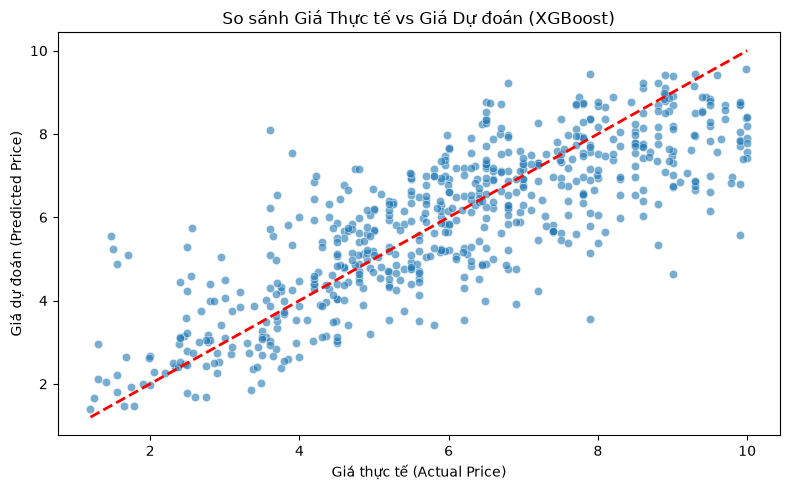

In [13]:
# --------------------------------------------------
# 9. ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
# --------------------------------------------------
y_pred_log = best_model.predict(X_test)
y_pred = np.expm1(y_pred_log)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n--- Kết quả đánh giá trên tập Test (giá trị thật) ---")
print(f"R2 Score : {r2:.4f}")
print(f"MAE      : {mae:,.2f}")
print(f"RMSE     : {rmse:,.2f}")
print(f"\nChênh lệch CV R2 ({best_cv_score:.4f}) vs Test R2 ({r2:.4f}): {abs(best_cv_score - r2):.4f}")

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Giá thực tế (Actual Price)")
plt.ylabel("Giá dự đoán (Predicted Price)")
plt.title(f"So sánh Giá Thực tế vs Giá Dự đoán ({best_model_name})")
plt.tight_layout()
plt.show()

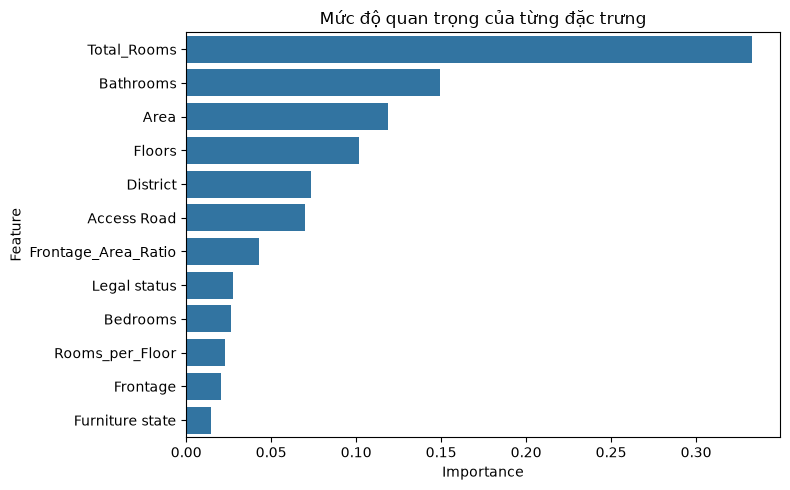

,Feature,Importance
10,Total_Rooms,0.332737
8,Bathrooms,0.149141
3,Area,0.118538
6,Floors,0.101419
2,District,0.073367
5,Access Road,0.069898
9,Frontage_Area_Ratio,0.042848
0,Legal status,0.027620
7,Bedrooms,0.026571
11,Rooms_per_Floor,0.022579



Đã xuất thành công mô hình TỐI ƯU RA: d:\05. CODE\DoAnNganh\RealEstateTrading\ml\models\best_model.pkl
Model được chọn: XGBoost | Test R2: 0.6522


In [14]:
# --------------------------------------------------
# 10. MỨC ĐỘ QUAN TRỌNG CỦA TỪNG ĐẶC TRƯNG
# --------------------------------------------------
feature_names = CAT_COLS + NUM_COLS
model_step = best_model.named_steps['model']

if hasattr(model_step, 'feature_importances_'):
    importances = model_step.feature_importances_
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x='Importance', y='Feature')
    plt.title('Mức độ quan trọng của từng đặc trưng')
    plt.tight_layout()
    plt.show()

    display(importance_df)
else:
    print(f"\nModel '{best_model_name}' không hỗ trợ feature_importances_.")

# --------------------------------------------------
# 11. LƯU MÔ HÌNH TỐI ƯU
# --------------------------------------------------
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

save_dict = {
    'model': best_model,
    'model_name': best_model_name,
    'feature_names': feature_names,
    'cat_cols': CAT_COLS,
    'num_cols': NUM_COLS,
    'log_transformed': True,
    'test_r2': r2,
    'test_mae': mae,
    'test_rmse': rmse,
}

joblib.dump(save_dict, MODEL_SAVE_PATH)
print(f"\nĐã xuất thành công mô hình TỐI ƯU RA: {MODEL_SAVE_PATH}")
print(f"Model được chọn: {best_model_name} | Test R2: {r2:.4f}")